In [1]:
import yaml
from typing import Literal, Annotated
from pydantic import BaseModel, Field
import openai

from shopping_assistant.env import load_env

from langgraph.graph import StateGraph, add_messages, START, END
from langchain_community.adapters.openai import convert_message_to_dict as convert_lc_message_to_openai_dict

from agents import Agent, function_tool, FunctionTool, Runner, set_tracing_disabled

import weaviate

import functools

## Env Vars

In [2]:
load_env()
set_tracing_disabled(True)

## Load config

In [3]:
with open("config.yml", "r") as f:
    CONFIG = yaml.safe_load(f)

## Initialize openai client

In [4]:
openai_client = openai.OpenAI()

## Get Clients

## LangGraph Workflow

### State

In [5]:
def add_messages_openai(messages_l, messages_r):

    messages_comb = add_messages(messages_l, messages_r)

    for idx, lc_msg in enumerate(messages_comb):
        try:
            messages_comb[idx] = convert_lc_message_to_openai_dict(lc_msg)
        except TypeError:
            pass

    return messages_comb

In [6]:
class Product(BaseModel):
    product_id: int
    name: str
    description: str
    category: str
    subcategory: str
    price: float

In [7]:
class State(BaseModel):
    messages: Annotated[list, add_messages_openai]
    prev_recommended_products: list[Product] | None = None

### Router Agent

In [8]:
downstream_routes_list = [d["name"] for d in CONFIG["agents"]["router"]["downstream_routes"]]

In [9]:

class DownstreamRoutesAgentResponse(BaseModel):
    route: Literal[*downstream_routes_list]

In [68]:
class RouterAgent:

    def __init__(self, config, openai_client: openai.OpenAI = openai.OpenAI()):
        self.config = config
        self.openai_client = openai_client


    def run(self, state: State) -> Literal[*downstream_routes_list]:
        input_messages = [
            {"role": "system", "content": self.config['prompts']['system_prompt']},
            *state.messages[:-1],
            {"role": "user", "content": f"Route based on this message: {state.messages[-1]['content']}"}
        ]

        response = openai_client.responses.parse(
            model=self.config["llm"],
            input=input_messages,
            text_format=DownstreamRoutesAgentResponse
        )

        return response.output_parsed.route

        

In [11]:
state = State(messages=[{"role": "user", "content": "I want to buy a new laptop."}])

router_agent = RouterAgent(config=CONFIG["agents"]["router"])

router_agent.run(state)

'product_search'

### Shopping Actions Agent

In [12]:
from collections import Counter


class Cart:
    def __init__(self, user_id: str):
        self.user_id = user_id
        self.items = Counter()

    def add_item(self, item_id: str, quantity: int):
        self.items[item_id] += quantity
        return self

    def remove_item(self, item_id: str, quantity: int):
        cur_qty = self.items.get(item_id, 0)
        if cur_qty < quantity:
            raise ValueError("Not enough quantity in cart")
        if cur_qty == quantity:
            return self.empty_item(item_id)
    
        self.items[item_id] -= quantity
        return self

    def empty_cart(self):
        self.items.clear()
        return self

    def empty_item(self, item_id: str):
        cur_qty = self.items.get(item_id, 0)
        if cur_qty == 0:
            raise ValueError("Item not found in cart")
            
        self.items.pop(item_id)
        return self

    def view_cart(self):
        return dict(self.items)

    def __repr__(self) -> str:
        return f'Cart({self.view_cart()})'

In [13]:
cart = Cart('123')

print(cart.view_cart())

cart.add_item('item_1', quantity=1)
print(cart.view_cart())

cart.remove_item('item_1', quantity=1)
print(cart.view_cart())

cart.empty_cart()
print(cart.view_cart())

{}
{'item_1': 1}
{}
{}


In [14]:
class ShoppingActionsAgent:

    def __init__(self, config, cart: Cart):
        self.config = config
        self.cart = cart
        self.tool_store = self._get_tool_store()
        self.agent_actions = self._define_agent_actions(self.tool_store)
        self.action_list = self._get_action_list(self.agent_actions)
        self.action_summary = self._get_action_summary(self.agent_actions)
        self.action_detailed = self._get_action_detailed(self.action_summary, self.agent_actions)
        self.system_prompt = self._build_system_prompt(self.action_list, self.action_summary, self.action_detailed)
        self.agent = self._build_agent(self.system_prompt)

    def _get_tool_store(self) -> dict[str, list[FunctionTool]]:
        return {
            "cart": self._get_cart_action_tools(),
        } 

    @property
    def tools(self):
        tools = []
        for action, tool_lst in self.tool_store.items():
            tools += tool_lst
        
        return tools

    def _get_cart_action_tools(self) -> list[FunctionTool]:

        @function_tool
        def add_to_cart(
            item_id: Annotated[str, "item_id"],
            quantity: Annotated[int, "quantity"] = 1
        ) -> dict:
            """Add an item to user's cart"""
            try:
                self.cart.add_item(item_id, quantity)
            except Exception as e:
                return "Error updating cart: " + str(e)
            
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def remove_from_cart(item_id: str, quantity: Annotated[int, "quantity"]) -> dict:
            """Remove an item from user's cart. Returns the updated cart."""
            self.cart.remove_item(item_id, quantity)
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def view_cart() -> dict:
            """View user's cart"""
            return self.cart.view_cart()

        @function_tool
        def empty_cart() -> str:
            """Empty user's cart"""
            self.cart.empty_cart()
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        @function_tool
        def empty_item(item_id: str) -> str:
            """Empty a specific item from user's cart"""
            self.cart.empty_item(item_id)
            return f"Cart updated successfully. Current Cart: {self.cart.view_cart()}"

        return [
            add_to_cart,
            remove_from_cart,
            view_cart,
            empty_cart,
            empty_item,
        ]

    def _define_agent_actions(self, tool_store: dict[str, list[FunctionTool]]) -> dict:
        agent_actions = {
            "cart": {
                "summary": "Manage your shopping cart (add or remove items, view cart)",
                "tools": tool_store["cart"],
            }
        }

        return agent_actions

    def _get_action_list(self, agent_actions: dict) -> list[str]:
        return list(agent_actions.keys())

    def _get_action_summary(self, agent_actions: dict) -> dict[str, str]:
        action_summary = {
            action_type: f"{idx + 1}. Action=`{action_type}`: {info['summary']}"
            for idx, (action_type, info) in enumerate(agent_actions.items())
        }

        return action_summary

    def _get_action_detailed(self, action_summary: dict[str, str], agent_actions: dict) -> dict[str, str]:
        action_detailed = ""
        for idx, (action_type, info) in enumerate(agent_actions.items()):
            action_detailed += action_summary[action_type] + "\n"
            for tool in info["tools"]:
                action_detailed += f"- Tool=`{tool.name}`: {tool.description}" + "\n"

        return action_detailed

    def _build_system_prompt(self, action_list: list[str], action_summary: dict[str, str], action_detailed: dict[str, str]) -> str:
        system_prompt = self.config['prompts']['system_prompt'].format(
            action_list=action_list,
            action_summary='\n'.join(action_summary.values()),
            action_detailed=action_detailed,
        )

        return system_prompt

    def _build_agent(self, system_prompt: str) -> Agent:
        return Agent(
            name='shopping_actions_agent',
            instructions=system_prompt,
            tools=self.tools,
            model=self.config['llm'],
        )
            
    async def run(self, state: State) -> State:
        response = await Runner.run(self.agent, state.messages)
        new_state = State(
            messages=[{"role": "assistant", "content": response.final_output}],
            prev_recommended_products=state.prev_recommended_products,
        )
        return new_state



In [15]:
state = State(
    messages=[
        {"role": "user", "content": "Can you please add item_123 to the cart?"}
    ]
)

In [16]:
cart = Cart(user_id="u_123")
shopping_actions_agent = ShoppingActionsAgent(CONFIG['agents']['shopping_actions'], cart)
new_state = await shopping_actions_agent.run(state)

In [17]:
print(new_state.messages[-1]['role'].upper(), ':', new_state.messages[-1]['content'])

ASSISTANT : Item `item_123` has been successfully added to your cart. Current Cart: {'item_123': 1}.


In [18]:
cart

Cart({'item_123': 1})

### Product Search Agent

In [19]:
from weaviate import WeaviateClient
import weaviate.classes as wvc


def get_product_list_prompt_str(products: list[Product]) -> str:
    prod_desc_lst = []
    for idx, prod in enumerate(products):
        prod_desc = f"{idx + 1}. {prod.name} (${prod.price})"
        prod_desc_lst.append(prod_desc)

    return '\n'.join(prod_desc_lst)

def _retrieve_products_client(
    weaviate_client: WeaviateClient,
    filter_obj: wvc.query.Filter,
    query: str = None,
    n: int = 5,
):
    products = weaviate_client.collections.use("products")
    
    if not query:
        response = products.query.fetch_objects(filters=filter_obj, limit=n)
    else:
        response = products.query.near_text(
            query=query,
            filters=filter_obj,
            limit=n,
        )
    
    return response

def retrieve_products(
    query: str = None,
    categories: list[str] = None,
    subcategories: list[str] = None,
    min_price: float = None,
    max_price: float = None,
    n: int = 5,
    weaviate_client: WeaviateClient = None,
):
    """
    Retrieve products from the catalog based on the given query and filters.
    """

    filters = []

    if categories:
        filters.append(
            wvc.query.Filter.by_property("category").contains_any(categories)
        )

    if subcategories:
        filters.append(
            wvc.query.Filter.by_property("subcategory").contains_any(subcategories)
        )

    if min_price:
        filters.append(
            wvc.query.Filter.by_property("price").greater_or_equal(min_price)
        )

    if max_price:
        filters.append(
            wvc.query.Filter.by_property("price").less_or_equal(max_price)
        )

    if filters:
        filter_obj = functools.reduce(
            lambda x, y: x & y,
            filters,
        )
    else:
        filter_obj = None

    if weaviate_client is None:
        with weaviate.connect_to_local() as weaviate_client:
            product_retrieval_response = _retrieve_products_client(
                weaviate_client=weaviate_client,
                filter_obj=filter_obj,
                query=query,
                n=n,
            )
    else:
        product_retrieval_response = _retrieve_products_client(
            weaviate_client=weaviate_client,
            filter_obj=filter_obj,
            query=query,
            n=n,
        )

    return product_retrieval_response


In [62]:
from weaviate import WeaviateClient

class ProductParsedDetails(BaseModel):
    category: str = Field(description="The category of the product")
    subcategory: str = Field(description="The subcategory of the product")
    min_price: float = Field(description="The minimum price of the product")
    max_price: float = Field(description="The maximum price of the product")

class ProductRetrievalAgentResponse(BaseModel):
    product_details: ProductParsedDetails | None = Field(description="The parsed details of the product. Populate ONLY if no clarification response is needed.")
    product_retrieval_query: str | None = Field(description="User query rephrased as a specific retrieval query for the product. Populate ONLY if no clarification response is needed.")
    product_clarification_response: str | None = Field(description="The clarification response for the user's query when no product details were parsed.")


class ProductSearchAgent:

    def __init__(self, config, openai_client: openai.OpenAI = openai.OpenAI(),  weaviate_client: WeaviateClient = None):
        self.config = config
        self.weaviate_client = weaviate_client
        self.openai_client = openai_client


    def run(self, state: State) -> State:

        if state.prev_recommended_products is not None:
            prev_recommended_products_prompt_str = get_product_list_prompt_str(state.prev_recommended_products)
        else:
            prev_recommended_products_prompt_str = "No products have been recommended to the user so far."

        system_prompt = self.config['prompts']['system_prompt'].format(
            catalog_hierarchy_tree=self.config['catalog_hierarchy_tree'],
            prev_recommended_products=prev_recommended_products_prompt_str
        )


        input_messages = [
            {'role': 'system', 'content': system_prompt},
            *state.messages,
            {'role': 'user', 'content': state.messages[-1]['content']}
        ]
        
        response = self.openai_client.responses.parse(
            model=self.config['llm'],
            input=input_messages,
            text_format=ProductRetrievalAgentResponse
        )

        prod_retrieval_agent_response = response.output_parsed



        if prod_retrieval_agent_response.product_clarification_response:
            new_state = State(
                messages=[{'role': 'assistant', 'content': prod_retrieval_agent_response.product_clarification_response}],
                prev_recommended_products=state.prev_recommended_products
            )

            return new_state
            
        product_retrieval_response = retrieve_products(
            query=prod_retrieval_agent_response.product_retrieval_query,
            categories=[prod_retrieval_agent_response.product_details.category] if prod_retrieval_agent_response.product_details.category else None,
            subcategories=[prod_retrieval_agent_response.product_details.subcategory] if prod_retrieval_agent_response.product_details.subcategory else None,
            min_price=prod_retrieval_agent_response.product_details.min_price,
            max_price=prod_retrieval_agent_response.product_details.max_price,
            weaviate_client=self.weaviate_client
        )

        products_retrieved = [Product(**p.properties) for p in product_retrieval_response.objects]

        if not product_retrieval_response.objects:
            asst_response = "I found no products based on your query. Can you please rephrase your query?"
        else:
            product_list_prompt_str = get_product_list_prompt_str(products_retrieved)
            asst_response = "I found the following products based on your query:\n\n" + product_list_prompt_str

        new_state = State(
            messages=[
                {"role": "assistant", "content": asst_response}
            ],
            prev_recommended_products=products_retrieved
        )

        return new_state
    
        

In [56]:
product_search_agent = ProductSearchAgent(CONFIG['agents']['product_search'], openai_client=openai_client)

In [22]:
state.messages

[{'role': 'user', 'content': 'Can you please add item_123 to the cart?'}]

In [23]:
state = State(
    messages=[
        {"role": "user", "content": "I am looking for black leather bags less than 50$"}
    ],
    prev_recommended_products=None,
)

res = product_search_agent.run(state)

In [24]:
res.prev_recommended_products

[Product(product_id=204, name='Classic Black Patent Leather Purse', description="Introducing the Classic Black Patent Bag, a blend of elegance and functionality that embodies timeless style and practical design. This stunning purse is crafted from patent leather, offering a chic and sophisticated accessory for any occasion.\nPair it with a summer dress and sandals to complete your look on a relaxed day out, or use it as a power statement for work. Its bold, timeless design amakes it a statement piece that adds elegance and sophistication to any ensemble.\nWith dimensions of 8 inches in height, 10 inches in length, and 3.9 inches in width, this purse offers ample space for all your essentials. Whether you're heading to the work, running errands, or traveling, the generous size ensures you can carry what you need with ease. The interior includes a zip pocket.\nThe purse features gold toned accents. The straps are crafted to provide durability ensuring they can withstand daily wear while 

In [25]:
print(res.messages[0]['content'])

I found the following products based on your query:

1. Classic Black Patent Leather Purse ($49.9)
2. Sleek Leather Satchel Bag ($49.99)
3. Ravenna Crossbody Bag ($49.99)
4. Embroidered Leather Bohemian Purse ($49.9)
5. Qwen Crossbody Bag ($39.99)


In [26]:
state = State(
    messages=[
        {"role": "user", "content": "Could you help me find relevant products for me? Perhaps what had been recommended to me earlier?"}
    ],
    prev_recommended_products=res.prev_recommended_products,
)

res_2 = product_search_agent.run(state)

In [27]:
print(res_2.messages[0]['content'])

Could you clarify what type of products you're looking for? Are you interested in accessories like bags or sunglasses, or perhaps something from apparel, footwear, or jewelry? I've previously recommended some bags, such as the Classic Black Patent Leather Purse and the Sleek Leather Satchel Bag.


### Customer Service Agent

In [63]:
class CustomerServiceAgent:
    def __init__(self, config, openai_client: openai.OpenAI = openai.OpenAI()):
        self.config = config
        self.openai_client = openai_client

    def run(self, state: State) -> State:
        input_messages = [
            {"role": "system", "content": self.config["prompts"]["system_prompt"]},
            *state.messages[:-1],
            {"role": "user", "content": state.messages[-1]["content"]}
        ]

        responses_obj = self.openai_client.chat.completions.create(
            model=self.config["llm"],
            messages=input_messages
        )

        response = {
            "role": "assistant",
            "content": responses_obj.choices[0].message.content
        }

        new_state = State(
            messages=[response],
            prev_recommended_products=state.prev_recommended_products
        )

        return new_state
        
        

In [29]:
state = State(
    messages=[
        {"role": "user", "content": "I need help with a past order."}
    ]
)

In [30]:
customer_service_agent = CustomerServiceAgent(CONFIG['agents']['customer_service'], openai_client)

new_state = customer_service_agent.run(state)

In [31]:
state.messages

[{'role': 'user', 'content': 'I need help with a past order.'}]

In [32]:
add_messages_openai(state.messages, new_state.messages)

[{'role': 'user', 'content': 'I need help with a past order.'},
 {'role': 'assistant',
  'content': 'Of course! I can help you with that. Could you please provide me with your order number or any additional details about the order?'}]

In [33]:
new_state

State(messages=[{'role': 'assistant', 'content': 'Of course! I can help you with that. Could you please provide me with your order number or any additional details about the order?'}], prev_recommended_products=None)

In [34]:
new_state.messages

[{'role': 'assistant',
  'content': 'Of course! I can help you with that. Could you please provide me with your order number or any additional details about the order?'}]

In [35]:
print(new_state.messages[-1]['role'].upper(), ':', new_state.messages[-1]['content'])

ASSISTANT : Of course! I can help you with that. Could you please provide me with your order number or any additional details about the order?


## Langraph Graph: Bring it all together!

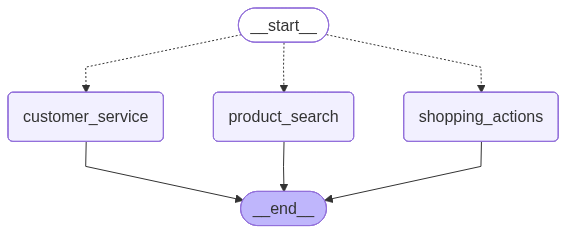

In [57]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

graph_builder = StateGraph(State)

graph_builder.add_conditional_edges(START, router_agent.run)

graph_builder.add_node("shopping_actions", shopping_actions_agent.run)
graph_builder.add_node("customer_service", customer_service_agent.run)
graph_builder.add_node("product_search", product_search_agent.run)

# graph_builder.add_edge(["shopping_actions", "customer_service"], END)
graph_builder.add_edge(["shopping_actions", "customer_service", "product_search"], END)

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

graph

In [37]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}

state = State(
    messages=[
        {"role": "user", "content": "I am looking for a black leather bag."}
    ]
)

await graph.ainvoke(state, config)

{'messages': [{'role': 'user',
   'content': 'I am looking for a black leather bag.'},
  {'role': 'assistant',
   'content': 'I found the following products based on your query:\n\n1. Classic Black Patent Leather Purse ($49.9)\n2. Opulent Leather Tote Bag ($99.99)\n3. Sleek Leather Satchel Bag ($49.99)\n4. Navy Leather Everyday Bag ($139.99)\n5. Fusion Leather Crossbody Bag ($109.99)'}],
 'prev_recommended_products': [Product(product_id=204, name='Classic Black Patent Leather Purse', description="Introducing the Classic Black Patent Bag, a blend of elegance and functionality that embodies timeless style and practical design. This stunning purse is crafted from patent leather, offering a chic and sophisticated accessory for any occasion.\nPair it with a summer dress and sandals to complete your look on a relaxed day out, or use it as a power statement for work. Its bold, timeless design amakes it a statement piece that adds elegance and sophistication to any ensemble.\nWith dimensions o

In [38]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}

state = State(
    messages=[
        {"role": "user", "content": "Can you add classic black patent leather purse to the cart?"}
    ]
)

await graph.ainvoke(state, config)

{'messages': [{'role': 'user',
   'content': 'I am looking for a black leather bag.'},
  {'role': 'assistant',
   'content': 'I found the following products based on your query:\n\n1. Classic Black Patent Leather Purse ($49.9)\n2. Opulent Leather Tote Bag ($99.99)\n3. Sleek Leather Satchel Bag ($49.99)\n4. Navy Leather Everyday Bag ($139.99)\n5. Fusion Leather Crossbody Bag ($109.99)'},
  {'role': 'user',
   'content': 'Can you add classic black patent leather purse to the cart?'},
  {'role': 'assistant',
   'content': 'The Classic Black Patent Leather Purse has been added to your cart successfully! Your current cart now includes the purse. If you need anything else, let me know!'}],
 'prev_recommended_products': [Product(product_id=204, name='Classic Black Patent Leather Purse', description="Introducing the Classic Black Patent Bag, a blend of elegance and functionality that embodies timeless style and practical design. This stunning purse is crafted from patent leather, offering a ch

In [39]:
cart.view_cart()

{'item_123': 1, 'classic_black_patent_leather_purse': 1}

In [40]:
config: RunnableConfig = {"configurable": {"thread_id": "1"}}

state = State(
    messages=[
        {"role": "user", "content": "Thanks! Now I wanna speak to the customer service agent."}
    ]
)

await graph.ainvoke(state, config)

{'messages': [{'role': 'user',
   'content': 'I am looking for a black leather bag.'},
  {'role': 'assistant',
   'content': 'I found the following products based on your query:\n\n1. Classic Black Patent Leather Purse ($49.9)\n2. Opulent Leather Tote Bag ($99.99)\n3. Sleek Leather Satchel Bag ($49.99)\n4. Navy Leather Everyday Bag ($139.99)\n5. Fusion Leather Crossbody Bag ($109.99)'},
  {'role': 'user',
   'content': 'Can you add classic black patent leather purse to the cart?'},
  {'role': 'assistant',
   'content': 'The Classic Black Patent Leather Purse has been added to your cart successfully! Your current cart now includes the purse. If you need anything else, let me know!'},
  {'role': 'user',
   'content': 'Thanks! Now I wanna speak to the customer service agent.'},
  {'role': 'assistant',
   'content': "I can help you with customer service inquiries right here! Please let me know what you need assistance with, and I'll do my best to help you."}],
 'prev_recommended_products':

## Chat

In [ ]:
class Chat:

    def __init__(
        self, 
        user_id: str, 
        config: dict,
        openai_client: openai.OpenAI = openai.OpenAI(),
        weaviate_client: WeaviateClient = None,
    ):
        self.user_id = user_id
        self.config = config
        self.openai_client = openai_client
        self.weaviate_client = weaviate_client
        
        self.cart = self._fetch_cart()
        self.agents = self._initialize_agents(cart=self.cart)
        self.memory = self._initialize_memory()
        self.graph = self._build_graph(agents=self.agents, memory=self.memory)
        self.set_thread("1")
    
    def _inner_thread_id(self):
        return f'{self.user_id}_{self.thread_id}'

    def set_thread(self, thread_id: str):
        self.thread_id = thread_id

    async def text_chat(self) -> str:

        thread_config: RunnableConfig = {"configurable": {"thread_id": self.thread_id}}

        while True:
            user_input = input("User: ")
            print("User: " + user_input)
            if user_input == "exit":
                print("Assistant: Goodbye!")
                return 
            
            state = State(messages=[
                {'role': 'user', 'content': user_input}
            ])
            new_state = await self.graph.ainvoke(state, thread_config)

            print("Assistant: " + new_state['messages'][-1]['content'])

    def ui_chat(self):

        async def chat(user_input: str, history):
            message = {'role': 'user', 'content': user_input}

            response = await self.graph.ainvoke(State(messages=[message]), config)

            return response['messages'][-1]['content']

        return gr.ChatInterface(fn=chat, title="Shopping Assistant", ).launch()        

    def _fetch_cart(self):
        return Cart(user_id=self.user_id)

    def _initialize_agents(self, cart: Cart):
        agents = {}

        agents["router"] = RouterAgent(self.config['agents']['router'], openai_client=self.openai_client)
        agents["shopping_actions"] = ShoppingActionsAgent(self.config['agents']['shopping_actions'], cart=cart)
        agents["product_search"] = ProductSearchAgent(self.config['agents']['product_search'], openai_client=self.openai_client, weaviate_client=self.weaviate_client)
        agents["customer_service"] = CustomerServiceAgent(self.config['agents']['customer_service'], openai_client=self.openai_client)

        return agents

    def _initialize_memory(self):
        return InMemorySaver()


    def _build_graph(self, agents: dict, memory: InMemorySaver):
        
        graph_builder = StateGraph(State)

        graph_builder.add_conditional_edges(START, agents["router"].run)

        graph_builder.add_node("shopping_actions", agents["shopping_actions"].run)
        graph_builder.add_node("customer_service", agents["customer_service"].run)
        graph_builder.add_node("product_search", agents["product_search"].run)
        graph_builder.add_edge(["shopping_actions", "customer_service", "product_search"], END)

        graph = graph_builder.compile(checkpointer=memory)

        return graph

        
        

In [109]:
chat = Chat(user_id="u123", config=CONFIG)

In [111]:
await chat.text_chat()

User: Hi!
Assistant: Hello! How can I assist you today?
User: Looking for black leather bags, any price :)
Assistant: I found the following products based on your query:

1. Classic Black Patent Leather Purse ($49.9)
2. Sleek Leather Satchel Bag ($49.99)
3. Opulent Leather Tote Bag ($99.99)
4. Navy Leather Everyday Bag ($139.99)
5. Fusion Leather Crossbody Bag ($109.99)
User: I like the 3rd one! Can you add it to the cart please (2 of them).
Assistant: I've added 2 Opulent Leather Tote Bags to your cart. If you need anything else, just let me know!
User: Can I see my cart?
Assistant: Here's what's in your cart:

- **Opulent Leather Tote Bag**: 2 items

If you need to make any changes or want to add more items, just let me know!
User: Yes, I have some questions on a past order I placed.
Assistant: Of course! Please provide me with the details of your past order or your order number, and I'll do my best to assist you.
User: exit
Assistant: Goodbye!


In [ ]:
chat.ui_chat()

/Users/Abhishek_Bhatia-GUVA/personal/projects/ecom-shopping-assistant/genai-shopping-assistant/.venv/lib/python3.12/site-packages/gradio/http_server.py:133: ResourceWarning: unclosed <socket.socket fd=130, family=2, type=1, proto=0, laddr=('0.0.0.0', 0)>
  s = socket.socket()
/Users/Abhishek_Bhatia-GUVA/personal/projects/ecom-shopping-assistant/genai-shopping-assistant/.venv/lib/python3.12/site-packages/gradio/http_server.py:133: ResourceWarning: unclosed <socket.socket fd=133, family=2, type=1, proto=0, laddr=('0.0.0.0', 0)>
  s = socket.socket()


* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


/Users/Abhishek_Bhatia-GUVA/personal/projects/ecom-shopping-assistant/genai-shopping-assistant/.venv/lib/python3.12/site-packages/gradio/routes.py:1350: DeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
/Users/Abhishek_Bhatia-GUVA/personal/projects/ecom-shopping-assistant/genai-shopping-assistant/.venv/lib/python3.12/site-packages/gradio/routes.py:1350: DeprecationWarning: 'HTTP_422_UNPROCESSABLE_ENTITY' is deprecated. Use 'HTTP_422_UNPROCESSABLE_CONTENT' instead.
  return await queue_join_helper(body, request, username)
